In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [18]:
# Chargement du fichier local
df = pd.read_csv("monthly-robberies.csv", index_col=0, parse_dates=True)

# Affichage des premières lignes pour vérification visuelle
print("Aperçu des données :")
print(df.head())
print("\nInformations structurelles :")
print(df.info())

Aperçu des données :
            Robberies
Month                
1966-01-01         41
1966-02-01         39
1966-03-01         50
1966-04-01         40
1966-05-01         43

Informations structurelles :
<class 'pandas.DataFrame'>
DatetimeIndex: 118 entries, 1966-01-01 to 1975-10-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Robberies  118 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB
None


In [5]:
# Vérification de la fréquence détectée
print(f"Fréquence actuelle : {df.index.freq}")

# Forcer la fréquence à 'MS' (Month Start) si elle n'est pas détectée
df.index.freq = 'MS'
print(f"Fréquence après correction : {df.index.freq}")

Fréquence actuelle : <MonthBegin>
Fréquence après correction : <MonthBegin>


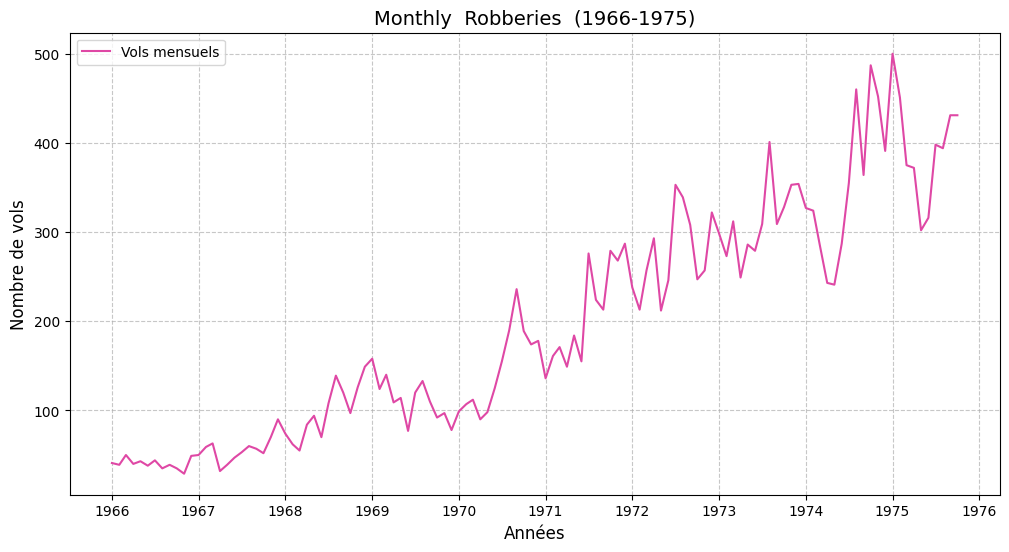

In [8]:
# Définir la taille de la figure
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Robberies'], color="#df48a5",  label='Vols mensuels')

# Ajouter les éléments de compréhension
plt.title('Monthly  Robberies  (1966-1975)', fontsize=14)
plt.xlabel('Années', fontsize=12)
plt.ylabel('Nombre de vols', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Afficher le graphique
plt.show()

In [10]:
# Calcul de la moyenne
moyenne = df['Robberies'].mean()

# Calcul de la variance
variance = df['Robberies'].var()

# Calcul de l'écart-type
ecart_type = df['Robberies'].std()


print(f"Moyenne : {moyenne:.2f}") 
print(f"Variance : {variance:.2f}") 
print(f"Écart-type : {ecart_type:.2f}")

print("\nRésumé complet :")
print(df.describe())


Moyenne : 196.29
Variance : 16395.16
Écart-type : 128.04

Résumé complet :
        Robberies
count  118.000000
mean   196.288136
std    128.043602
min     29.000000
25%     85.500000
50%    166.000000
75%    296.750000
max    500.000000


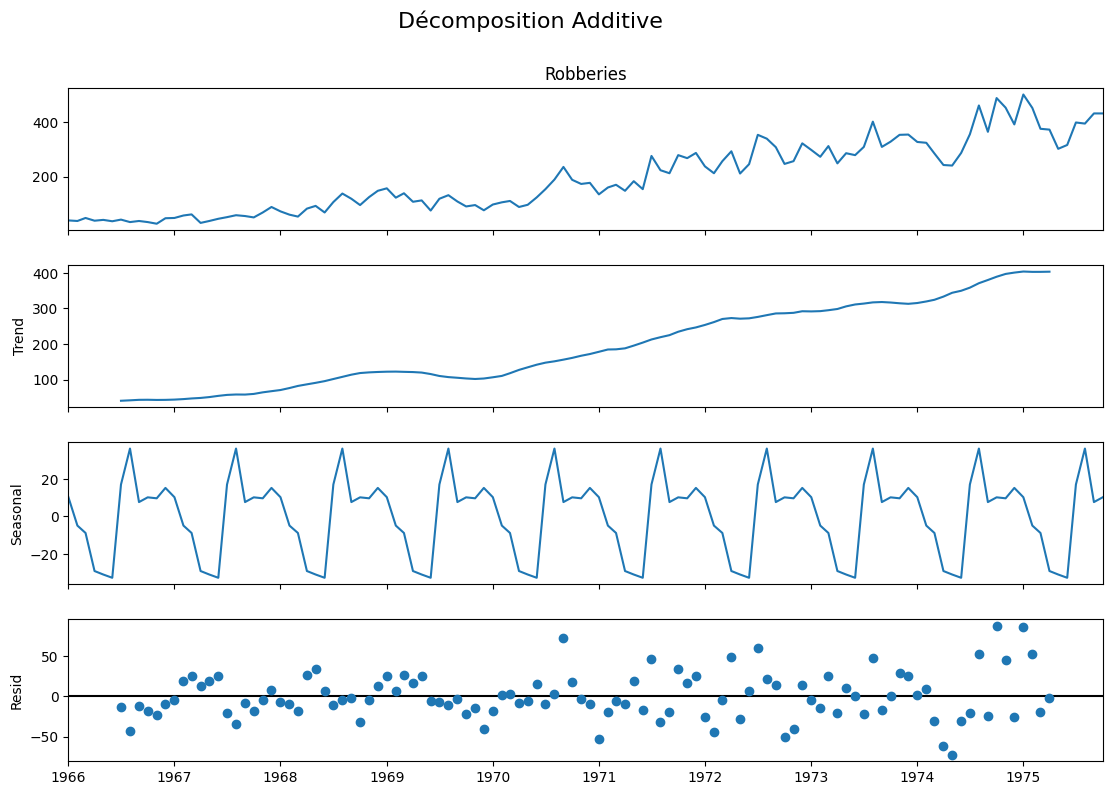

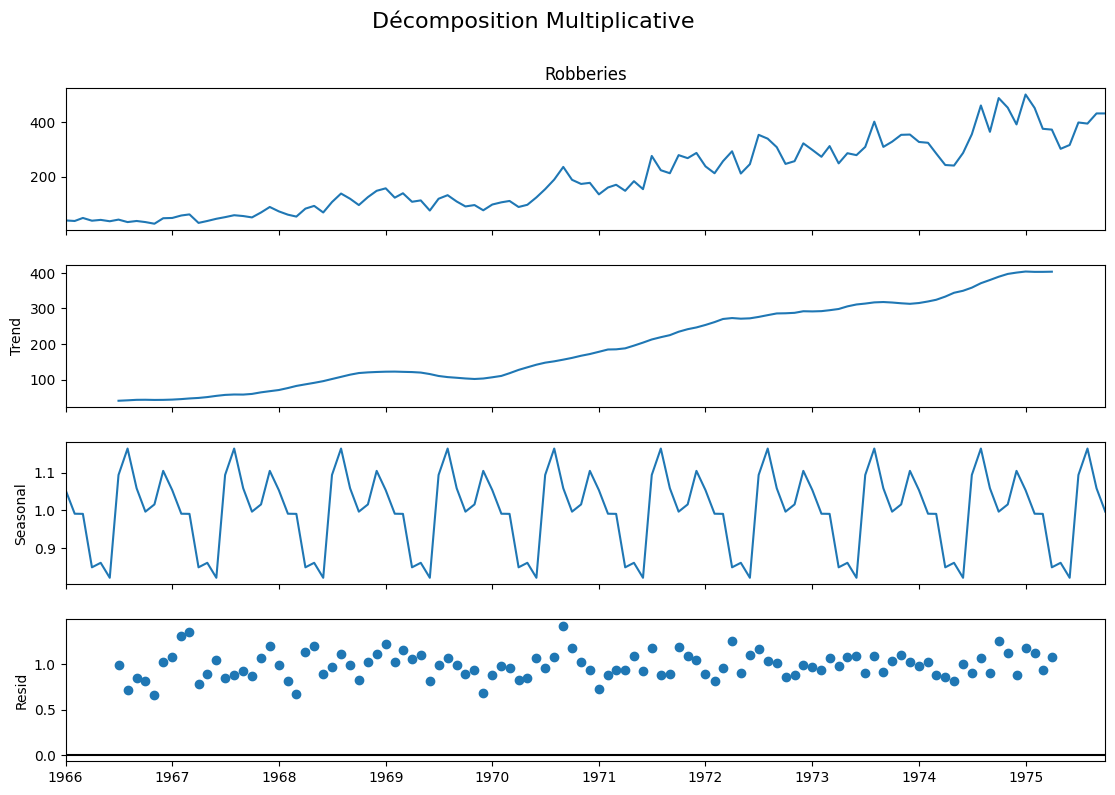

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Décomposition Additive
add_decomp = seasonal_decompose(df['Robberies'], model='additive', period=12)

# Affichage du modèle additif
fig1 = add_decomp.plot()
fig1.set_size_inches(12, 8) # Taille plus adaptée pour la visibilité
plt.suptitle('Décomposition Additive', fontsize=16, y=1.02) # y=1.02 remonte le titre
plt.show()

# 2. Décomposition Multiplicative
mult_decomp = seasonal_decompose(df['Robberies'], model='multiplicative', period=12)

# Affichage du modèle multiplicatif
fig2 = mult_decomp.plot()
fig2.set_size_inches(12, 8)
plt.suptitle('Décomposition Multiplicative', fontsize=16, y=1.02)
plt.show()